<a href="https://colab.research.google.com/github/y0n1k/bc2024-1/blob/main/ML_lab1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Лабораторна робота 1. Лінійна регресія, оптимізація та статистичний аналіз
Мета: зрозуміти архітектуру лінійної регресії, навчитися самостійно реалізовувати алгоритми оптимізації, обирати інформативні ознаки, обчислювати метрики та перевіряти статистичні припущення моделі

Датасет: **Ames Housing**. Цільова змінна — `SalePrice`.

Хід роботи:
1. EDA і відбір ознак
2. Лінійна регресія на numpy
3. Три варіанти градієнтного спуску
4. R² і оцінка якості
5. Перевірка статистичних припущень
6. Експеримент Б (Learning Rate)

In [ ]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from pathlib import Path

warnings.filterwarnings("ignore")
np.random.seed(42)
pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 140)

## Етап 1. EDA, відбір ознак і попередня обробка

Завантажено дані. Прибрано у колонках пробіли (`Gr Liv Area`), щоб назви були як у Kaggle-версії.

In [ ]:
URL = "https://raw.githubusercontent.com/rasbt/machine-learning-book/main/ch09/AmesHousing.txt"
if Path("AmesHousing.csv").exists():
    df = pd.read_csv("AmesHousing.csv")
else:
    df = pd.read_csv(URL, sep="\t")
    df.to_csv("AmesHousing.csv", index=False)

df.columns = [c.replace(" ", "") for c in df.columns]
df = df.rename(columns={"YearRemod/Add": "YearRemodAdd"})
df = df.drop(columns=["Order", "PID"])

print(df.shape)
df.head()

(2930, 80)


,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,...,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,NAmes,Norm,Norm,1Fam,1Story,6,5,1960,1960,...,2.0,528.0,TA,TA,P,210,62,0,0,0,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,NAmes,Feedr,Norm,1Fam,1Story,5,6,1961,1961,...,1.0,730.0,TA,TA,Y,140,0,0,0,120,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
2,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,NAmes,Norm,Norm,1Fam,1Story,6,6,1958,1958,...,1.0,312.0,TA,TA,Y,393,36,0,0,0,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
3,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,AllPub,Corner,Gtl,NAmes,Norm,Norm,1Fam,1Story,7,5,1968,1968,...,2.0,522.0,TA,TA,Y,0,0,0,0,0,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
4,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,Gilbert,Norm,Norm,1Fam,2Story,5,5,1997,1998,...,2.0,482.0,TA,TA,Y,212,34,0,0,0,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900


In [ ]:
# типи ознак і пропуски
print("Числових:", df.select_dtypes(include=[np.number]).shape[1])
print("Категоріальних:", df.select_dtypes(exclude=[np.number]).shape[1])

na = df.isna().sum()
na = na[na > 0].sort_values(ascending=False)
print("\nТоп-10 колонок з пропусками:")
print(na.head(10))

Числових: 37
Категоріальних: 43

Топ-10 колонок з пропусками:
PoolQC         2917
MiscFeature    2824
Alley          2732
Fence          2358
MasVnrType     1775
FireplaceQu    1422
LotFrontage     490
GarageQual      159
GarageCond      159
GarageYrBlt     159
dtype: int64


In [ ]:
df[["SalePrice", "GrLivArea", "LotArea", "OverallQual", "YearBuilt"]].describe().round(1)

,SalePrice,GrLivArea,LotArea,OverallQual,YearBuilt
count,2930.0,2930.0,2930.0,2930.0,2930.0
mean,180796.1,1499.7,10147.9,6.1,1971.4
std,79886.7,505.5,7880.0,1.4,30.2
min,12789.0,334.0,1300.0,1.0,1872.0
25%,129500.0,1126.0,7440.2,5.0,1954.0
50%,160000.0,1442.0,9436.5,6.0,1973.0
75%,213500.0,1742.8,11555.2,7.0,2001.0
max,755000.0,5642.0,215245.0,10.0,2010.0


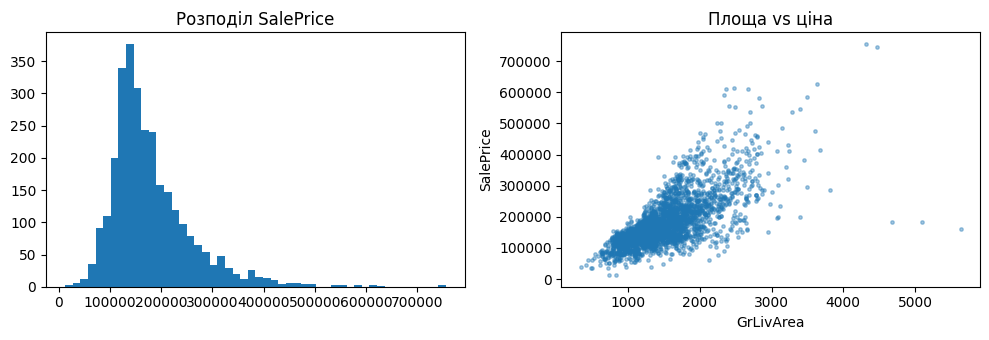

Асиметрія SalePrice: 1.74


In [ ]:
plt.figure(figsize=(10, 3.5))
plt.subplot(1, 2, 1)
plt.hist(df["SalePrice"], bins=50)
plt.title("Розподіл SalePrice")
plt.subplot(1, 2, 2)
plt.scatter(df["GrLivArea"], df["SalePrice"], s=6, alpha=0.4)
plt.xlabel("GrLivArea"); plt.ylabel("SalePrice")
plt.title("Площа vs ціна")
plt.tight_layout(); plt.show()

print("Асиметрія SalePrice:", round(stats.skew(df["SalePrice"]), 2))

Ціна має довгий правий хвіст (асиметрія ~= 1.7), тобто є кілька дуже дорогих будинків.
На другому графіку видно 3 точки з величезною площею і низькою ціною - це викиди, автор датасету радить прибирати будинки з `GrLivArea > 4000`. Їх усунуто.

In [ ]:
df = df[df["GrLivArea"] <= 4000].reset_index(drop=True)
print("Залишилось рядків:", len(df))

Залишилось рядків: 2925


### Кореляції

In [ ]:
num = df.select_dtypes(include=[np.number])
corr = num.corr()["SalePrice"].drop("SalePrice").sort_values(ascending=False)
print(corr.head(12).round(3))

OverallQual     0.805
GrLivArea       0.719
TotalBsmtSF     0.659
GarageCars      0.653
GarageArea      0.648
1stFlrSF        0.643
YearBuilt       0.565
FullBath        0.544
YearRemodAdd    0.540
GarageYrBlt     0.534
MasVnrArea      0.513
TotRmsAbvGrd    0.498
Name: SalePrice, dtype: float64


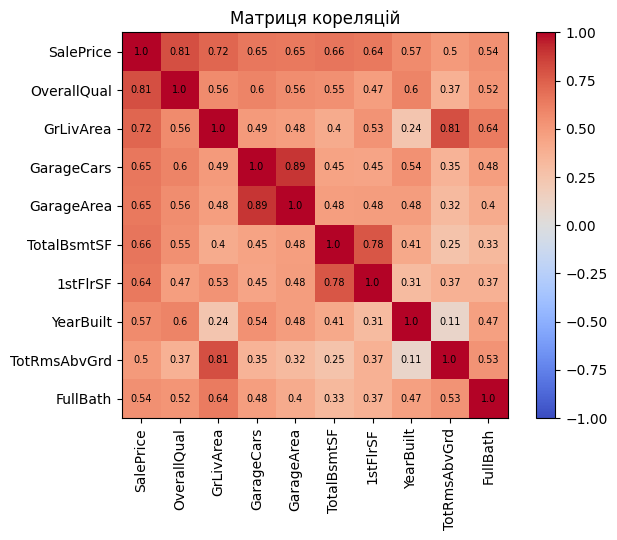

In [ ]:
top = ["SalePrice", "OverallQual", "GrLivArea", "GarageCars", "GarageArea",
       "TotalBsmtSF", "1stFlrSF", "YearBuilt", "TotRmsAbvGrd", "FullBath"]
C = num[top].corr()

plt.figure(figsize=(7, 5.5))
plt.imshow(C, cmap="coolwarm", vmin=-1, vmax=1)
plt.xticks(range(len(top)), top, rotation=90)
plt.yticks(range(len(top)), top)
plt.colorbar()
for i in range(len(top)):
    for j in range(len(top)):
        plt.text(j, i, round(C.iloc[i, j], 2), ha="center", va="center", fontsize=7)
plt.title("Матриця кореляцій")
plt.tight_layout(); plt.show()

**Вибір ознак.** Взято ті числові ознаки, у яких кореляція з ціною більша за ~0.4.
З пар, які сильно корелюють між собою (мультиколінеарність), залишено по одній ознаці:

* `GarageCars` і `GarageArea` (r = 0.89) → залишено `GarageCars`;
* `GrLivArea` і `TotRmsAbvGrd` (r = 0.81) → залишено `GrLivArea`;
* `TotalBsmtSF` і `1stFlrSF` (r = 0.78) → залишено `TotalBsmtSF`.

Багато ознак майже порожні (`PoolQC`, `Alley`) або слабо пов'язані з ціною,
від них тільки більше шуму.

З категоріальних взято `Neighborhood` (район сильно впливає на ціну), `BldgType`, `HouseStyle`
і якісні оцінки `KitchenQual`, `ExterQual`.

In [ ]:
NUM = ["OverallQual", "GrLivArea", "TotalBsmtSF", "GarageCars", "YearBuilt",
       "YearRemodAdd", "MasVnrArea", "Fireplaces", "FullBath", "LotArea"]
ORD = ["KitchenQual", "ExterQual"]          # мають порядок: Po < Fa < TA < Gd < Ex
CAT = ["Neighborhood", "BldgType", "HouseStyle"]

print("Всього ознак до кодування:", len(NUM) + len(ORD) + len(CAT))

Всього ознак до кодування: 15


### Розбиття на Train / Validation / Test

Зроблено розбиття 60/20/20 до кодування і масштабування.

In [ ]:
idx = np.random.RandomState(42).permutation(len(df))
n_tr, n_va = int(0.6 * len(df)), int(0.2 * len(df))

train = df.iloc[idx[:n_tr]].reset_index(drop=True)
val   = df.iloc[idx[n_tr:n_tr + n_va]].reset_index(drop=True)
test  = df.iloc[idx[n_tr + n_va:]].reset_index(drop=True)

y_tr = train["SalePrice"].to_numpy(float)
y_va = val["SalePrice"].to_numpy(float)
y_te = test["SalePrice"].to_numpy(float)

print(len(train), len(val), len(test))

1755 585 585


**Питання: чому розбивати дані треба до масштабування/кодування? Що таке Data Leakage.**

Data Leakage - це коли в модель потрапляє інформація з тестових даних, якої в реальності на момент прогнозу не було б. Через це оцінка якості виходить завищеною, а на нових даних модель працює гірше.

Масштабування, заповнення пропусків, кодування - це теж навчувані операції, вони мають параметри (середнє, стандартне відхилення, медіана, список категорій). Якщо порахувати їх на всьому датасеті, то в них потрапить інформація з тесту, і тест перестане бути чесною перевіркою. Тому спочатку розбиття, потім параметри рахуємо на Train і застосовуємо їх до Val і Test.

### Кодування категорій

**Питання: One-Hot, Ordinal чи Target Encoding?**

* `KitchenQual` і `ExterQual` мають природний порядок (Po < Fa < TA < Gd < Ex), тому
  **Ordinal Encoding**: Po=1 ... Ex=5. Виходить одна колонка замість п'яти.
* `Neighborhood`, `BldgType`, `HouseStyle` - порядку немає, тому **One-Hot**. Якби їх було закодовано числами 1...27, модель вирішила б, що один район "більший" за інший, а це неправда.
* Target Encoding не підходить: він рахується через цільову змінну, і без додаткових хитрощів легко отримати витік даних.

**Питання: що робити з категоріями, яких не було в Train?**

Список колонок фіксовано по Train. Для Val/Test зроблено `reindex` по цих колонках: якщо трапляється нова категорія, всі її dummy-колонки будуть нулями, тобто модель сприйме її як "базовий" варіант. Розмірність не ламається і код не падає.

In [ ]:
qual_map = {"Ex": 5, "Gd": 4, "TA": 3, "Fa": 2, "Po": 1}

def make_X(d, columns=None):
    X = d[NUM].astype(float).copy()
    for c in ORD:
        X[c] = d[c].map(qual_map).fillna(0)
    X = pd.concat([X, pd.get_dummies(d[CAT], dtype=float)], axis=1)
    if columns is not None:              # підганяю під колонки Train
        X = X.reindex(columns=columns, fill_value=0.0)
    return X

X_tr = make_X(train)
cols = X_tr.columns
X_va = make_X(val, cols)
X_te = make_X(test, cols)

# пропуски заповнюю медіаною з Train
med = X_tr.median()
X_tr, X_va, X_te = X_tr.fillna(med), X_va.fillna(med), X_te.fillna(med)

print("Колонок після кодування:", X_tr.shape[1])
new_cat = (set(val["Neighborhood"]) | set(test["Neighborhood"])) - set(train["Neighborhood"])
print("Категорії Neighborhood, яких немає в Train:", new_cat)

Колонок після кодування: 52
Категорії Neighborhood, яких немає в Train: {'Landmrk'}


### Масштабування

Стандартизовано тільки числові та порядкові ознаки. Середнє і стандартне відхилення розраховано лише на Train.

In [ ]:
scale_cols = NUM + ORD
mu = X_tr[scale_cols].mean()
sd = X_tr[scale_cols].std()

for X in (X_tr, X_va, X_te):
    X[scale_cols] = (X[scale_cols] - mu) / sd

X_tr = X_tr.to_numpy(float)
X_va = X_va.to_numpy(float)
X_te = X_te.to_numpy(float)

print(X_tr.shape, X_va.shape, X_te.shape)
print("Середнє на Train (має бути ~0):", round(X_tr[:, :len(scale_cols)].mean(), 6))

(1755, 52) (585, 52) (585, 52)
Середнє на Train (має бути ~0): -0.0


## Етап 2. Лінійна регресія на numpy

Модель: $\hat y = Xw + b$.

Функція втрат (MSE): $J = \frac{1}{m}\sum (\hat y - y)^2$.

Градієнти: $\frac{\partial J}{\partial w} = \frac{2}{m}X^T(\hat y - y)$, $\frac{\partial J}{\partial b} = \frac{2}{m}\sum(\hat y - y)$.

In [ ]:
def predict(X, w, b):
    return X @ w + b

def mse_loss(X, y, w, b):
    r = predict(X, w, b) - y
    return float(np.mean(r ** 2))

def gradients(X, y, w, b):
    m = len(y)
    r = predict(X, w, b) - y
    dw = 2 * (X.T @ r) / m
    db = 2 * r.mean()
    return dw, db

def update(w, b, dw, db, alpha):
    return w - alpha * dw, b - alpha * db

def r2_score(y, y_pred):
    ss_res = np.sum((y - y_pred) ** 2)
    ss_tot = np.sum((y - y.mean()) ** 2)
    return 1 - ss_res / ss_tot

## Етап 3. Три варіанти градієнтного спуску

Одна функція на всі три випадки, відрізняється тільки розмір батча:
* `batch_size=None` — Batch GD (вся вибірка);
* `batch_size=1` — SGD;
* `batch_size=64` — Mini-batch GD.

Критерій зупинки: зміна втрат менша за 0.0001 % або досягнута максимальна кількість епох.

In [ ]:
def train_gd(X, y, alpha=0.01, epochs=200, batch_size=None, seed=42):
    m, n = X.shape
    w, b = np.zeros(n), 0.0
    B = m if batch_size is None else batch_size
    rng = np.random.default_rng(seed)
    history = [mse_loss(X, y, w, b)]

    for ep in range(epochs):
        order = np.arange(m) if batch_size is None else rng.permutation(m)
        for s in range(0, m, B):
            i = order[s:s + B]
            dw, db = gradients(X[i], y[i], w, b)
            w, b = update(w, b, dw, db, alpha)

        loss = mse_loss(X, y, w, b)
        history.append(loss)
        if not np.isfinite(loss) or loss > 1e20:        # розбіглось
            break
        if abs(history[-2] - loss) / history[-2] < 1e-6:
            break
    return w, b, history

### Підбір Learning Rate

Випробувано кілька значень і оцінюю R² на валідації.

In [ ]:
setups = {
    "Batch GD":   (None, [0.3, 0.1, 0.05, 0.01], 500),
    "SGD":        (1,    [0.01, 0.005, 0.002, 0.001], 20),
    "Mini-batch": (64,   [0.1, 0.05, 0.02, 0.01], 100),
}

rows, best_alpha = [], {}
for name, (bs, alphas, ep) in setups.items():
    best, best_r2 = None, -np.inf
    for a in alphas:
        w, b, h = train_gd(X_tr, y_tr, alpha=a, epochs=ep, batch_size=bs)
        r2 = r2_score(y_va, predict(X_va, w, b)) if np.isfinite(h[-1]) else np.nan
        ok = np.isfinite(r2) and r2 > 0
        rows.append({"метод": name, "alpha": a, "R2_val": round(r2, 4) if ok else "розбіглось"})
        if ok and r2 > best_r2:
            best, best_r2 = a, r2
    best_alpha[name] = best

print(pd.DataFrame(rows).to_string(index=False))
print("\nОбрані alpha:", best_alpha)

     метод  alpha     R2_val
  Batch GD  0.300 розбіглось
  Batch GD  0.100     0.8607
  Batch GD  0.050     0.8591
  Batch GD  0.010     0.8415
       SGD  0.010     0.7458
       SGD  0.005     0.8365
       SGD  0.002     0.8529
       SGD  0.001     0.8559
Mini-batch  0.100     0.8568
Mini-batch  0.050     0.8607
Mini-batch  0.020     0.8608
Mini-batch  0.010     0.8594

Обрані alpha: {'Batch GD': 0.1, 'SGD': 0.001, 'Mini-batch': 0.02}


In [ ]:
models, hists = {}, {}
max_ep = {"Batch GD": 2000, "SGD": 50, "Mini-batch": 300}

for name, (bs, _, _) in setups.items():
    w, b, h = train_gd(X_tr, y_tr, alpha=best_alpha[name], epochs=max_ep[name], batch_size=bs)
    models[name] = (w, b)
    hists[name] = h
    print(f"{name:12} alpha={best_alpha[name]:<6} епох={len(h)-1:<5} "
          f"MSE_train={h[-1]:,.0f}  R2_val={r2_score(y_va, predict(X_va, w, b)):.4f}")

Batch GD     alpha=0.1    епох=2000  MSE_train=685,510,104  R2_val=0.8604


SGD          alpha=0.001  епох=50    MSE_train=693,613,813  R2_val=0.8590
Mini-batch   alpha=0.02   епох=300   MSE_train=688,365,001  R2_val=0.8608


### Графік Cost Function від кількості епох

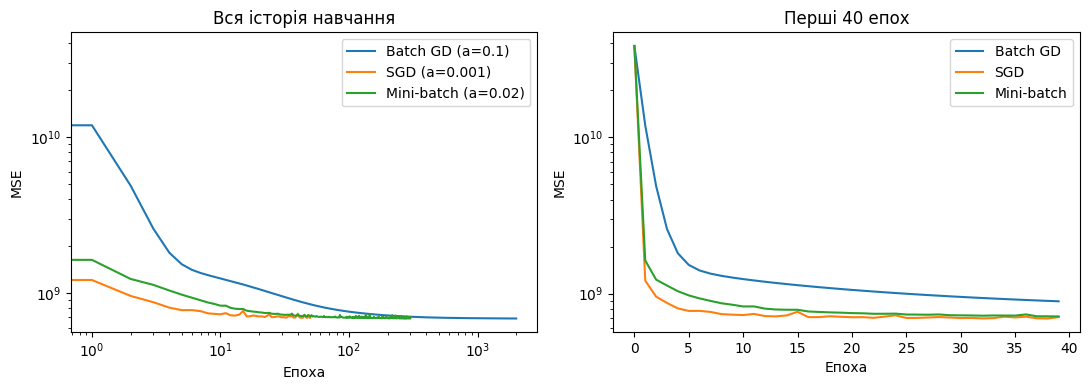

In [ ]:
plt.figure(figsize=(11, 4))
plt.subplot(1, 2, 1)
for name in setups:
    plt.plot(hists[name], label=f"{name} (a={best_alpha[name]})")
plt.yscale("log"); plt.xscale("log")
plt.xlabel("Епоха"); plt.ylabel("MSE"); plt.legend(); plt.title("Вся історія навчання")

plt.subplot(1, 2, 2)
for name in setups:
    plt.plot(hists[name][:40], label=name)
plt.yscale("log")
plt.xlabel("Епоха"); plt.ylabel("MSE"); plt.legend(); plt.title("Перші 40 епох")
plt.tight_layout(); plt.show()

**Аналіз графіків:**

* **Найстабільніше збігається Batch GD** - крива гладка і падає без стрибків, бо градієнт рахується по всій вибірці, тобто він точний. Але за одну епоху робиться лише одне оновлення ваг, тому епох потрібно багато.
* **Найбільші коливання у SGD** - ваги оновлюються по одному прикладу, кожен приклад тягне в свій бік, тому крива смикається і в кінці модель не зупиняється в мінімумі, а крутиться біля нього.
* **Розмір батча:** чим більший батч, тим гладкіша крива і тим більший крок можна ставити, але тим менше оновлень за епоху. Mini-batch (B=64) — компроміс: майже така сама гладкість, як у Batch GD, але потрібні десятки епох, а не тисячі.
* **Learning Rate:** замалий - навчання дуже повільне, завеликий - модель перестрибує мінімум і втрати ростуть. Видно і з таблиці підбору: для Batch GD працює alpha≈0.1, а для SGD те саме значення вже завелике.

## Етап 4. Оцінка якості та R²

$R^2 = 1 - \frac{\sum(y - \hat y)^2}{\sum(y - \bar y)^2}$

In [ ]:
res = []
for name, (w, b) in models.items():
    row = {"метод": name}
    for split, (X, y) in {"Train": (X_tr, y_tr), "Val": (X_va, y_va), "Test": (X_te, y_te)}.items():
        p = predict(X, w, b)
        row["R2 " + split] = round(r2_score(y, p), 4)
        row["RMSE " + split] = round(np.sqrt(mse_loss(X, y, w, b)))
    res.append(row)

pd.DataFrame(res)

,метод,R2 Train,RMSE Train,R2 Val,RMSE Val,R2 Test,RMSE Test
0,Batch GD,0.8899,26182,0.8604,28880,0.8840,26750
1,SGD,0.8886,26337,0.8590,29023,0.8830,26857
2,Mini-batch,0.8894,26237,0.8608,28834,0.8823,26937


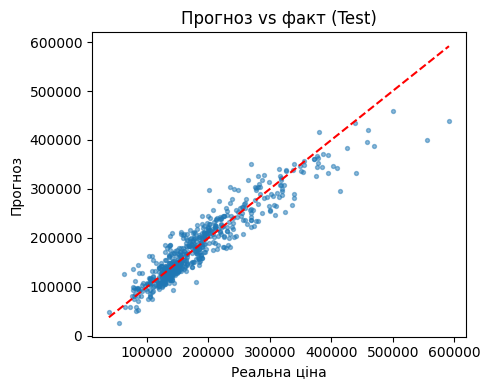

In [ ]:
w, b = models["Mini-batch"]
p_te = predict(X_te, w, b)

plt.figure(figsize=(5, 4))
plt.scatter(y_te, p_te, s=8, alpha=0.5)
plt.plot([y_te.min(), y_te.max()], [y_te.min(), y_te.max()], "r--")
plt.xlabel("Реальна ціна"); plt.ylabel("Прогноз")
plt.title("Прогноз vs факт (Test)")
plt.tight_layout(); plt.show()

In [ ]:
# перевірка, чи може R2 бути від'ємним
w_bad, b_bad, _ = train_gd(X_tr, y_tr, alpha=0.01, epochs=1)
print("Модель після 1 епохи, R2 на тесті:", round(r2_score(y_te, predict(X_te, w_bad, b_bad)), 3))
print("Якщо завжди прогнозувати середню ціну, R2 на тесті:",
      round(r2_score(y_te, np.full_like(y_te, y_tr.mean())), 3))

Модель після 1 епохи, R2 на тесті: -4.901
Якщо завжди прогнозувати середню ціну, R2 на тесті: -0.005


**Відповіді на питання:**

* **Що показує R².** Це частка розкиду ціни, яку модель пояснює. R²=1 - ідеальний прогноз, R²=0 - модель не краща за те, щоб завжди називати середню ціну.
* **Чи може бути від'ємним.** Так, якщо модель гірша за середнє значення. Вище показано: якщо зупинити навчання після 1 епохи, ваги ще майже нульові і R² виходить сильно від'ємним. Так само буває на тесті, якщо модель сильно перенавчена.
* **Train vs Test.** R² на Train ~= 0.89, на Test ~= 0.88. Різниця маленька, значить перенавчання немає. Модель радше трохи недонавчена - лінійна залежність не описує всі нюанси ціни.
* **Порівняння трьох методів.** Результати майже однакові (різниця в третьому знаку), бо задача опукла і мінімум один. Відрізняється тільки шлях до нього: Batch GD - багато епох, Mini-batch - десятки, SGD - найшвидше за епохами, але трохи гірша точність через шум.

## Етап 5. Перевірка статистичних припущень

Залишки $\epsilon = y - \hat y$ моделі Mini-batch на валідаційній вибірці.

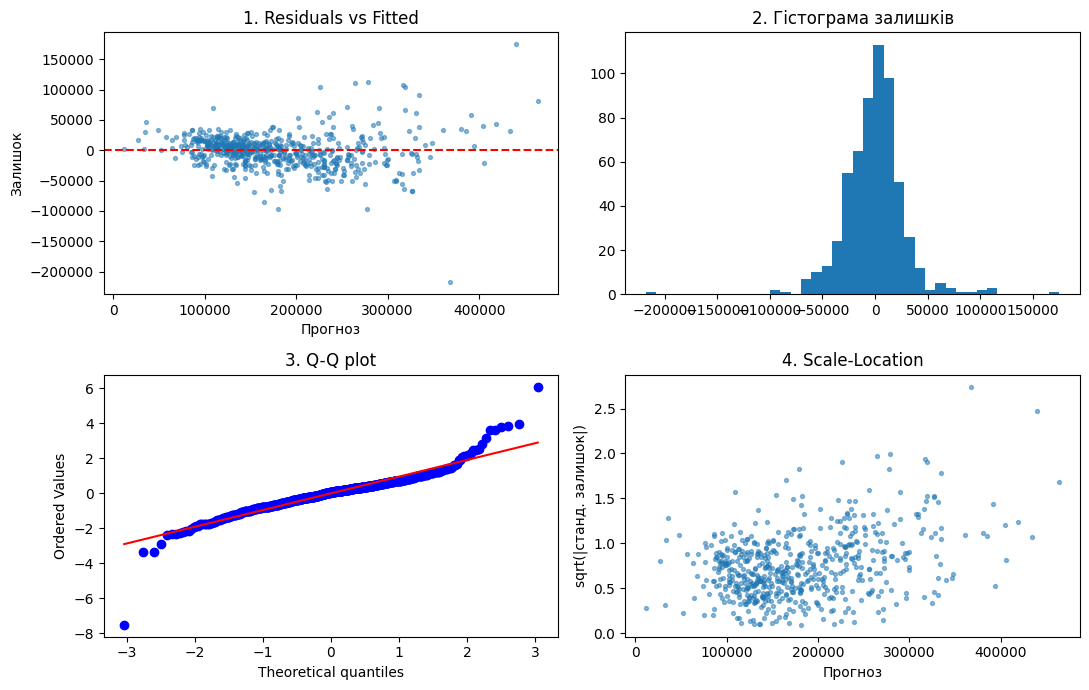

In [ ]:
fitted = predict(X_va, *models["Mini-batch"])
resid = y_va - fitted
resid_std = (resid - resid.mean()) / resid.std()

fig, ax = plt.subplots(2, 2, figsize=(11, 7))

ax[0, 0].scatter(fitted, resid, s=8, alpha=0.5)
ax[0, 0].axhline(0, color="r", ls="--")
ax[0, 0].set_xlabel("Прогноз"); ax[0, 0].set_ylabel("Залишок")
ax[0, 0].set_title("1. Residuals vs Fitted")

ax[0, 1].hist(resid, bins=40)
ax[0, 1].set_title("2. Гістограма залишків")

stats.probplot(resid_std, dist="norm", plot=ax[1, 0])
ax[1, 0].set_title("3. Q-Q plot")

ax[1, 1].scatter(fitted, np.sqrt(np.abs(resid_std)), s=8, alpha=0.5)
ax[1, 1].set_xlabel("Прогноз"); ax[1, 1].set_ylabel("sqrt(|станд. залишок|)")
ax[1, 1].set_title("4. Scale-Location")

plt.tight_layout(); plt.show()

In [ ]:
print("Тест Шапіро-Уїлка:", stats.shapiro(resid))
print("Асиметрія залишків:", round(stats.skew(resid), 2))

# середній залишок по групах (дешеві -> дорогі)
groups = pd.qcut(fitted, 4, labels=["дешеві", "нижче сер.", "вище сер.", "дорогі"])
print("\nЗалишки по групах (від дешевих до дорогих):")
print(pd.DataFrame({"залишок": resid}).groupby(groups, observed=True)
      .agg(середній=("залишок", "mean"), розкид=("залишок", "std")).round(0))

Тест Шапіро-Уїлка: ShapiroResult(statistic=np.float64(0.9116522753838294), pvalue=np.float64(5.965562023662717e-18))
Асиметрія залишків: -0.06

Залишки по групах (від дешевих до дорогих):
            середній   розкид
дешеві        7919.0  16527.0
нижче сер.   -1948.0  18689.0
вище сер.    -6205.0  24328.0
дорогі       -3485.0  44940.0


In [ ]:
# VIF для числових ознак
def vif(X):
    out = []
    for j in range(X.shape[1]):
        yj = X[:, j]
        Xj = np.c_[np.ones(len(X)), np.delete(X, j, axis=1)]
        beta = np.linalg.lstsq(Xj, yj, rcond=None)[0]
        r2 = r2_score(yj, Xj @ beta)
        out.append(1 / (1 - r2))
    return np.array(out)

k = len(scale_cols)
print(pd.DataFrame({"VIF": vif(X_tr[:, :k]).round(2)}, index=scale_cols)
      .sort_values("VIF", ascending=False))

               VIF
OverallQual   3.52
ExterQual     2.97
GrLivArea     2.60
KitchenQual   2.55
YearBuilt     2.43
FullBath      2.16
YearRemodAdd  2.15
GarageCars    1.93
TotalBsmtSF   1.62
Fireplaces    1.41
MasVnrArea    1.33
LotArea       1.15


**Висновки по припущеннях:**

1. **Лінійність — частково порушується**, тому що на графіку Residuals vs Fitted залишки лежать не рівномірно навколо нуля: у групі дешевих будинків середній залишок +7.9 тис., а у двох верхніх групах — від'ємний (−6.2 і −3.5 тис.). Це означає, що модель занижує ціну дешевих будинків і завищує ціну дорожчих, тобто справжня залежність не зовсім пряма лінія.

2. **Нормальність залишків порушується**, тому що на Q-Q plot точки на краях сильно відходять від прямої, а тест Шапіро-Уїлка дає p-value майже нуль. Це означає, що самі прогнози рахувати можна, але довірчі інтервали і тести значущості коефіцієнтів будуть неточними.

3. **Гомоскедастичність порушується**, тому що на графіку Scale-Location хмара точок піднімається вправо, і це видно в числах: розкид залишків у групі дешевих будинків 16.5 тис., а у дорогих — 45 тис. Тобто помилка не однакова по всьому діапазону цін, для дорогих будинків модель помиляється сильніше.

4. **Мультиколінеарність відсутня**, тому що всі VIF менші за 5 (найбільші — у `OverallQual` і `YearBuilt`, близько 3). Це тому, що на етапі відбору навмисно викинуто `GarageArea`, `1stFlrSF` і `TotRmsAbvGrd`, які дублювали інші ознаки.

**Чи вплинула мультиколінеарність на коефіцієнти.** Мультиколінеарність не нашкодила моделі, бо заздалегідь усунуто ознаки-дублікати. Завдяки цьому програма чітко розуміє логіку: наприклад, що велика площа чи кращий ремонт завжди підвищують ціну. Якби залишилися схожі дані (скажімо, розмір гаража у квадратах і в кількості авто), модель би просто заплуталася, якій з цих двох колонок приписати більшу вартість, і її розрахунки стали б хаотичними та непередбачуваними.

## Етап 6. Експеримент Б (Learning Rate)

Для кожного з трьох методів знайдено alpha, при якому навчання розходиться (втрати ростуть або стають `inf`/`nan`).

In [ ]:
grid = [0.001, 0.005, 0.01, 0.05, 0.1, 0.2, 0.3, 0.5, 1.0]

tab, diverged_hist = [], {}
for name, (bs, _, _) in setups.items():
    for a in grid:
        w, b, h = train_gd(X_tr, y_tr, alpha=a, epochs=20, batch_size=bs)
        bad = (not np.isfinite(h[-1])) or h[-1] > 10 * h[0]
        tab.append({"метод": name, "alpha": a,
                    "MSE в кінці": "inf / nan" if not np.isfinite(h[-1]) else f"{h[-1]:.3e}",
                    "стан": "розходиться" if bad else "працює"})
        if bad and name not in diverged_hist:
            diverged_hist[name] = (a, h)

tab = pd.DataFrame(tab)
print(tab.pivot(index="alpha", columns="метод", values="стан").to_string())
print("\nНайменше alpha, при якому розходиться:")
for name in setups:
    print(f"  {name:12} -> {diverged_hist[name][0] if name in diverged_hist else '> 1.0'}")

метод     Batch GD   Mini-batch          SGD
alpha                                       
0.001       працює       працює       працює
0.005       працює       працює       працює
0.010       працює       працює       працює
0.050       працює       працює  розходиться
0.100       працює       працює  розходиться
0.200  розходиться  розходиться  розходиться
0.300  розходиться  розходиться  розходиться
0.500  розходиться  розходиться  розходиться
1.000  розходиться  розходиться  розходиться

Найменше alpha, при якому розходиться:
  Batch GD     -> 0.2
  SGD          -> 0.05
  Mini-batch   -> 0.2


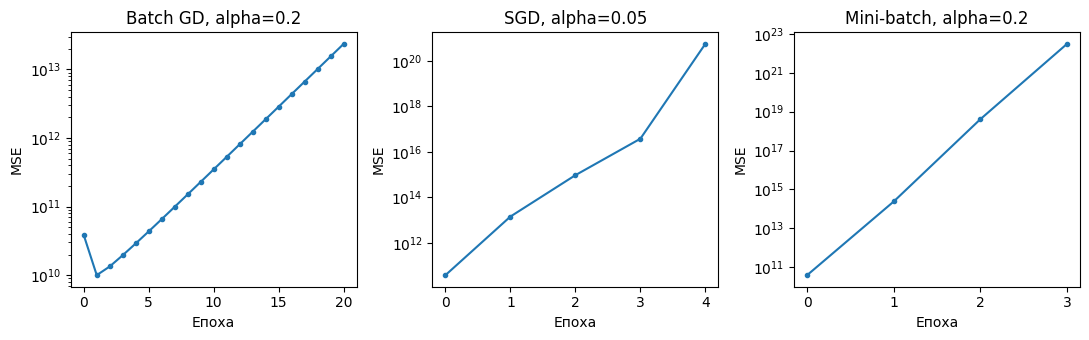

In [ ]:
plt.figure(figsize=(11, 3.5))
for i, name in enumerate(setups):
    plt.subplot(1, 3, i + 1)
    a, h = diverged_hist[name]
    plt.plot(np.array(h, dtype=float), marker="o", ms=3)
    plt.yscale("log")
    plt.title(f"{name}, alpha={a}")
    plt.xlabel("Епоха"); plt.ylabel("MSE")
plt.tight_layout(); plt.show()

**Аналіз.** На графіках видно однакову картину: замість того, щоб падати, MSE росте на кілька порядків за кілька епох і далі стає `inf`. Це і є розбіжність — крок настільки великий, що кожне оновлення перестрибує мінімум і опиняється далі від нього, ніж було.

**Чому чутливість різна.** Batch GD і Mini-batch розходяться при одному й тому ж alpha = 0.2, а SGD — уже при 0.05, тобто приблизно в 4 рази раніше. Причини:

* Batch GD рахує градієнт по всій вибірці, тобто це усереднений напрямок. Для нього є теоретична межа кроку, і поки alpha менше неї, втрати обов'язково падають.
* SGD рахує градієнт по одному прикладу. Якщо трапляється нетиповий будинок (дуже велика площа, рідкісний район), його градієнт великий, і один такий крок може відкинути ваги дуже далеко. А за епоху таких кроків робиться стільки,скільки прикладів, тому помилка швидко наростає.
* Mini-batch усереднює градієнт по 64 прикладах, тому окремі дивні приклади вже не так впливають, і поведінка близька до Batch GD.

Висновок: чим менший батч, тим менший learning rate треба ставити.

## Висновки

* Побудовано лінійну регресію на numpy і навчано її трьома варіантами градієнтного спуску.
* Якість приблизно однакова у всіх трьох: R² ~= 0.89 на Train і ~= 0.88 на Test (RMSE ~= 27 тис.  при середній ціні 180 тис.). Перенавчання немає.
* Batch GD найстабільніший, але найповільніший за епохами; SGD найшумніший; Mini-batch - найзручніший компроміс.
* Припущення нормальності та однакової дисперсії залишків порушуються, мультиколінеарності немає (VIF < 5). Тобто для прогнозу модель годиться, а для точних статистичних висновків про коефіцієнти — не дуже.
* В Експерименті Б підтвердилось, що SGD розходиться при меншому learning rate (0.05), ніж Batch GD і Mini-batch (0.2).